In [2]:
import jax
import jax.numpy as jnp
from jax import random, grad, jit, vmap, value_and_grad,lax
import jax.nn as nn
from jax.tree_util import tree_map
import matplotlib.pyplot as plt

In [3]:
#CONFIG
cfg = {
    "B": 32,
    "L": 128,
    "H": 8,
    "dh": 16,
    "D": 128,
    "d_ff": 512,
    "seed": 0,
    "eps": 1e-5,
    "n_layers": 4,
    "lr": 3e-4,
    "steps_per_epoch": 100,
    "val_steps": 20,
    "n_epochs": 80,
}
key = random.key(cfg["seed"])
key_init, key_data, key_train, key_misc = random.split(key,4)

In [4]:
#Lorenz
sigma,rho,beta = 10.0, 27.0, 8.0/3.0
dt = 1e-2
T = 1000
s0 = random.uniform(key_data,shape=(3,),
                    minval=-1.0,maxval=1.0)

def lorenz_rhs(s,sigma,rho,beta):
    x,y,z = s
    dx = sigma*(y-x)
    dy = x*(rho-z)-y
    dz = x*y-beta*z
    return jnp.array([dx,dy,dz],dtype=s.dtype)

def euler_step(s,dt,sigma,rho,beta):
    return s+dt*lorenz_rhs(s,sigma,rho,beta)

def scan_step(carry,_):
    s = carry
    s_next = euler_step(s,dt,sigma,rho,beta)
    return s_next,s_next

final_state,traj = jax.lax.scan(scan_step,s0,xs=None,length=T)

print("# Shapes: ")
print("\ts0 = ", s0.shape)
print("\tfinal_state = ", final_state.shape)
print("\ttraj =", traj.shape)
print("\nfinal_state = ", final_state)

# Shapes: 
	s0 =  (3,)
	final_state =  (3,)
	traj = (1000, 3)

final_state =  [10.415074   0.3739915 37.57996  ]


In [5]:
#Dataset(batches)
def make_batch(key_data,cfg):
    T = cfg["L"]+1
    keys = random.split(key_data,cfg["B"])

    def sample_s0(key):
        s0 = random.uniform(key,shape=(3,),
                        minval=-1.0,maxval=1.0)
        return s0

    s0_batch = vmap(sample_s0)(keys) #(Bx3)
    assert s0_batch.shape == (cfg["B"],3)

    def simulate_lorenz(s0):
        final_state,traj = jax.lax.scan(scan_step,s0,xs=None,length=T)
        return final_state,traj #(3,),(T,3)

    _,traj_batch = vmap(simulate_lorenz)(s0_batch) #(B,T,3)
    assert traj_batch.shape == (cfg["B"],T,3)

    X = traj_batch[:,:-1,:] #(B,L,3)
    Y = traj_batch[:,1:,:]  #(B,L,3)
    
    assert X.shape == (cfg["B"],cfg["L"],3);assert Y.shape == (cfg["B"],cfg["L"],3)
    return X,Y

In [6]:
#Positional Encoding
assert cfg["D"]%2==0

def build_positional_encoding(L,D):
    positions = jnp.arange(L,dtype=jnp.float32)[:,None] #(L,1)
    dims = jnp.arange(D,dtype=jnp.float32)[None,:] #(1,D)

    div_term = 10000.0**(2.0*(dims//2)/D)    #(1,D)
    angles=positions/div_term                #(L,D)

    even_mask = (jnp.arange(D)%2==0)[None,:] #(1,D)

    P = jnp.where(even_mask,jnp.sin(angles), #(L,D)
                  jnp.cos(angles))
    return P

P = build_positional_encoding(cfg["L"], cfg["D"])


In [7]:
def input_proj(X,params):
    return X@params["W"]+params["b"]

In [8]:
#LayerNorm
def layer_norm(X,params,eps=1e-5):
    gamma = params["gamma"];beta = params["beta"]
    mew = jnp.mean(X,axis=-1,keepdims=True)          #(B,L,1)
    var = jnp.mean((X-mew)**2,axis=-1,keepdims=True) #(B,L,1)

    X_hat = (X-mew)/(jnp.sqrt(var+eps))
    Y = gamma*X_hat+beta
    return Y

In [9]:
#Casual Mask
def build_casual_mask(cfg):
    L = cfg["L"]
    upper = jnp.triu(jnp.ones((L, L), dtype=jnp.float32),k=1) #s-u-t
    M = jnp.where(upper==1,-1e9,0.0)[None,None,:,:]
    assert M.shape == (1, 1, cfg["L"], cfg["L"])
    return M

M = build_casual_mask(cfg)
print("M shape ->", M.shape)

M shape -> (1, 1, 128, 128)


In [34]:
#Multi-Head Attention
key_wq,key_wk,key_wv,key_wo = random.split(key_init,4)

def linear_proj(X,W,b):
    return X@W+b

H = cfg["H"]
dh = cfg["dh"]
B = cfg["B"]
L = cfg["L"]
D = cfg["D"]

def mha(X,params,M,return_attn=False):

    B,L,Dcur = X.shape
    
    W_q = params["W_q"];W_k = params["W_k"];W_v=params["W_v"]
    b_q = params["b_q"];b_k = params["b_k"];b_v=params["b_v"]
    Q = linear_proj(X,W_q,b_q).reshape(B,L,H,dh)
    K = linear_proj(X,W_k,b_k).reshape(B,L,H,dh)
    V = linear_proj(X,W_v,b_v).reshape(B,L,H,dh)

    Q = jnp.transpose(Q, (0,2,1,3))
    K = jnp.transpose(K, (0,2,1,3))
    V = jnp.transpose(V, (0,2,1,3))

    #Scores
    S = jnp.einsum("bhid,bhjd->bhij",Q,K)
    assert S.shape == (B,H,L,L)
    S /= jnp.sqrt(dh)
    S_m = S+M

    #softmax         #key position
    A = nn.softmax(S_m,axis=-1)
    assert A.shape == (B,H,L,L)

    #Context
    C = jnp.einsum("bhij,bhjd->bhid",A,V)
    assert C.shape == (B,H,L,dh)

    #Merge heads
    C = jnp.transpose(C,(0,2,1,3))
    C = C.reshape(B,L,Dcur)

    #Output projection
    Y = C@params["W_o"]+params["b_o"]
    assert Y.shape == (B,L,Dcur)

    if return_attn:
        return Y,A

    return Y

In [11]:
#FNN
key_w1,key_w2 = random.split(key_init,2)

def ffn(X,params):
    H = X@params["W1"]+params["b1"]
    H = nn.gelu(H)
    Y = H@params["W2"]+params["b2"]
    return Y

In [35]:
#Decoder Blockc
eps = cfg["eps"]

def decoder_block(X,ln1_params,mha_params,ln2_params,ffn_params,M,return_attn=False):
    X_ln1 = layer_norm(X,ln1_params,eps)

    if return_attn:
        attn_out,A = mha(X_ln1,mha_params,M,return_attn=True)
    else:
        attn_out = mha(X_ln1,mha_params,M,return_attn=False)
    
    X = X+attn_out

    X_ln2 = layer_norm(X,ln2_params,eps)
    ffn_out = ffn(X_ln2,ffn_params)
    X = X+ffn_out

    if return_attn:
        return X,A

    return X

In [13]:
#Full Decoder Block
def init_params(key_init,D,d_ff,n_layers):
    keys = random.split(key_init,2+2*n_layers)

    fan_in,fan_out = 3,D
    std_in = jnp.sqrt(2.0/(fan_in+fan_out))

    input_proj = {
        "W": std_in * random.normal(keys[0], shape=(fan_in, fan_out)),
        "b": jnp.zeros((fan_out,), dtype=jnp.float32),
    }

    blocks = []
    std_mha = 1.0 / jnp.sqrt(D)
    std_ff1 = jnp.sqrt(2.0 / (D + d_ff))
    std_ff2 = jnp.sqrt(2.0 / (d_ff + D))

    for i in range(n_layers):
        key_mha = keys[1+2*i]
        key_ffn = keys[2+2*i]

        kq,kk,kv,ko = random.split(key_mha,4)
        k1,k2 = random.split(key_ffn,2)

        block = {
            "ln1": {
                "gamma": jnp.ones((D,), dtype=jnp.float32),
                "beta": jnp.zeros((D,), dtype=jnp.float32),
            },
            "mha": {
                "W_q": std_mha * random.normal(kq, shape=(D, D)),
                "b_q": jnp.zeros((D,), dtype=jnp.float32),
                "W_k": std_mha * random.normal(kk, shape=(D, D)),
                "b_k": jnp.zeros((D,), dtype=jnp.float32),
                "W_v": std_mha * random.normal(kv, shape=(D, D)),
                "b_v": jnp.zeros((D,), dtype=jnp.float32),
                "W_o": std_mha * random.normal(ko, shape=(D, D)),
                "b_o": jnp.zeros((D,), dtype=jnp.float32),
            },
            "ln2": {
                "gamma": jnp.ones((D,), dtype=jnp.float32),
                "beta": jnp.zeros((D,), dtype=jnp.float32),
            },
            "ffn": {
                "W1": std_ff1 * random.normal(k1, shape=(D, d_ff)),
                "b1": jnp.zeros((d_ff,), dtype=jnp.float32),
                "W2": std_ff2 * random.normal(k2, shape=(d_ff, D)),
                "b2": jnp.zeros((D,), dtype=jnp.float32),
            },
        }
        blocks.append(block)

    #out proj
    std_out = jnp.sqrt(2.0/(D+3))
    out_proj = {
        "W": std_out * random.normal(keys[-1], shape=(D, 3)),
        "b": jnp.zeros((3,), dtype=jnp.float32)
    }
    params = {
    "input_proj": input_proj,
    "blocks": blocks,
    "out_proj": out_proj,
    }
    return params

params = init_params(key_init,cfg["D"],cfg["d_ff"],cfg["n_layers"])


In [36]:
#forward
def forward(params,X,P,M,return_attn=False,attn_block_idx=0):

    #input projection
    X = input_proj(X,params["input_proj"]) #(B,L,3)->(B,L,D)

    #positional encoding
    X = X+P #(B,L,D)

    attn_map = None

    #stack decoder blocks
    for i,block in enumerate(params["blocks"]):
        if return_attn and attn_block_idx == i:
            X,attn_map = decoder_block(X,block["ln1"],block["mha"],
                block["ln2"],block["ffn"],M,return_attn=True)
        else:
            X = decoder_block(X,block["ln1"],block["mha"],
                block["ln2"],block["ffn"],M)
        
    #output projection
    Y_hat = X@params["out_proj"]["W"]+params["out_proj"]["b"] #(B,L,D)

    if return_attn:
        return Y_hat, attn_map
    return Y_hat

In [15]:
#Loss
def loss_fn(params,X,Y,P,M):
    Y_hat = forward(params,X,P,M) #(B,L,3)
    loss = jnp.mean((Y_hat-Y)**2)
    return loss


In [16]:
def init_adam_state(params):
    m = jax.tree.map(lambda p: jnp.zeros_like(p),params)
    v = jax.tree.map(lambda p: jnp.zeros_like(p),params)
    t = jnp.array(0,dtype=jnp.int32)
    return {"m":m, "v":v, "t":t}

def adam_step(params,grads,state,lr=1e-3,beta1=0.9,beta2=0.999,eps=1e-8):
    t = state["t"] + 1

    m = jax.tree.map(
        lambda m_old, g: beta1 * m_old + (1.0 - beta1)*g, state["m"],grads)
    v = jax.tree.map(
        lambda v_old,g: beta2*v_old+(1.0-beta2)*(g*g),state["v"],grads)
    
    m_hat = jax.tree.map(lambda x: x/(1.0-beta1**t),m)
    v_hat = jax.tree.map(lambda x: x/(1.0-beta2**t),v)
    
    params = jax.tree.map(
        lambda p, m_h,v_h: p-lr*m_h/(jnp.sqrt(v_h)+eps),
        params,m_hat,v_hat
    )

    new_state = {"m":m,"v":v,"t":t}
    return params, new_state

In [17]:
def train_step(params,adam_state,X,Y,P,M):
    loss, grads = jax.value_and_grad(loss_fn)(params,X,Y,P,M)
    params,adam_state = adam_step(params,grads,adam_state,lr=cfg["lr"])
    return params,adam_state,loss

train_step_jit = jax.jit(train_step)

In [18]:
def eval_step(params,X,Y,P,M):
    return loss_fn(params,X,Y,P,M)

eval_step = jax.jit(eval_step)

In [19]:
#Train loop
def train_model(params,cfg,key_train,key_val,P,M):
    adam_state = init_adam_state(params)

    train_losses = []
    val_losses = []

    for epoch in range(cfg["n_epochs"]):
        epoch_train_losses = []

        #trainig batches
        epoch_key = random.fold_in(key_train,epoch)
        batch_keys = random.split(epoch_key,cfg["steps_per_epoch"])

        for step in range(cfg["steps_per_epoch"]):
            X_batch,Y_batch = make_batch(batch_keys[step],cfg)
            params,adam_state,loss = train_step_jit(params,adam_state,X_batch,Y_batch,P,M)
            epoch_train_losses.append(loss)

        mean_train_loss = jnp.mean(jnp.array(epoch_train_losses))
        train_losses.append(mean_train_loss)

        #validation
        val_epoch_key = random.fold_in(key_val,epoch)
        val_batch_keys = random.split(val_epoch_key,cfg["val_steps"])

        epoch_val_losses = []
        for vstep in range(cfg["val_steps"]):
            X_val,Y_val = make_batch(val_batch_keys[vstep],cfg)
            val_loss = eval_step(params,X_val,Y_val,P,M)
            epoch_val_losses.append(val_loss)

        mean_val_loss = jnp.mean(jnp.array(epoch_val_losses))
        val_losses.append(mean_val_loss)

        print(f"epoch={epoch+1:d} train_loss={float(mean_train_loss):.6f} val_loss={float(mean_val_loss):.6f}")

        history = {
            "train_loss":jnp.array(train_losses),
            "val_loss": jnp.array(val_losses)
        }
    return params, adam_state, history

In [33]:
import sys
import jax
import jax.numpy as jnp

print("backend:", jax.default_backend())
print("devices:", jax.devices())
print("x on:", jnp.ones((1024, 1024)).devices())


backend: gpu
devices: [CudaDevice(id=0)]
x on: {CudaDevice(id=0)}


In [21]:
params = init_params(key_init, cfg["D"],cfg["d_ff"],cfg["n_layers"])
M = build_casual_mask(cfg)

key_train,key_val = random.split(key_train,2)
params,adam_state, history = train_model(params,cfg,key_train,key_val,P,M)

E0313 10:51:31.912566    7484 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


epoch=1 train_loss=19.514727 val_loss=0.602241
epoch=2 train_loss=0.328297 val_loss=0.185766
epoch=3 train_loss=0.133647 val_loss=0.093846
epoch=4 train_loss=0.074448 val_loss=0.055098
epoch=5 train_loss=0.045684 val_loss=0.036003
epoch=6 train_loss=0.030586 val_loss=0.025838
epoch=7 train_loss=0.022486 val_loss=0.020045
epoch=8 train_loss=0.017387 val_loss=0.016163
epoch=9 train_loss=0.013762 val_loss=0.013295
epoch=10 train_loss=0.012153 val_loss=0.010249
epoch=11 train_loss=0.010176 val_loss=0.009016
epoch=12 train_loss=0.008672 val_loss=0.008444
epoch=13 train_loss=0.007596 val_loss=0.007383
epoch=14 train_loss=0.006994 val_loss=0.006506
epoch=15 train_loss=0.006243 val_loss=0.006778
epoch=16 train_loss=0.006144 val_loss=0.005777
epoch=17 train_loss=0.005422 val_loss=0.006428
epoch=18 train_loss=0.005756 val_loss=0.007369
epoch=19 train_loss=0.005610 val_loss=0.004384
epoch=20 train_loss=0.006125 val_loss=0.004097
epoch=21 train_loss=0.006812 val_loss=0.003176
epoch=22 train_loss=0

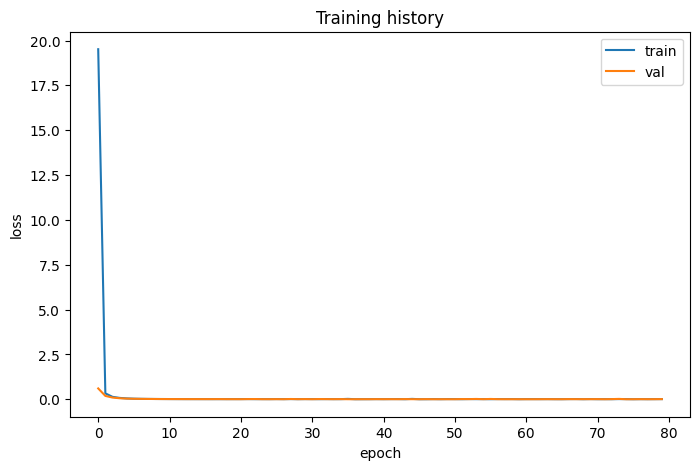

In [22]:
plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], label="train")
plt.plot(history["val_loss"], label="val")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Training history")
plt.legend()
plt.show()

In [28]:
#Long true traj for rollout
rollout_steps = 200
T_long = cfg["L"]+rollout_steps

key_roll = random.fold_in(key_misc,rollout_steps)
s0_roll = random.uniform(key_roll,shape=(3,),minval=-1.0,maxval=1.0)

final_state_long, traj_long = jax.lax.scan(scan_step,s0_roll,xs=None,
                                           length=T_long)
assert traj_long.shape == (T_long, 3)

In [29]:
seed_window = traj_long[:cfg["L"], :]                       #(L,3)
true_future = traj_long[cfg["L"]:cfg["L"]+rollout_steps, :] #(rollout_steps,3)



In [30]:
#Rollout
window = seed_window[None,:,:] #(1,L,3)
preds = []

for step in range(rollout_steps):
    Y_hat = forward(params,window,P,M) #(1,L,3)
    s_next = Y_hat[:,-1,:] #(1,3)
    preds.append(s_next[0]) #(3,)
    window = jnp.concatenate([window[:,1:,:],s_next[:,None,:]],axis=1) #(1,L,3)

preds = jnp.stack(preds,axis=0) #(rollout_steps,3)
assert preds.shape == (rollout_steps,3)
assert true_future.shape == (rollout_steps,3)

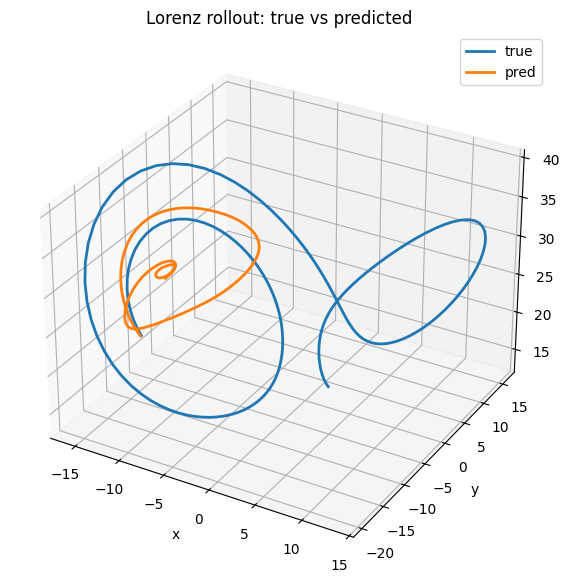

In [31]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(9,7))
ax = fig.add_subplot(111,projection="3d")

#real
ax.plot(true_future[:,0],true_future[:,1],true_future[:,2],
        label="true",linewidth=2)
#predicted
ax.plot(preds[:,0],preds[:,1],preds[:,2],
        label="pred",linewidth=2)


ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("Lorenz rollout: true vs predicted")
ax.legend()
plt.show()

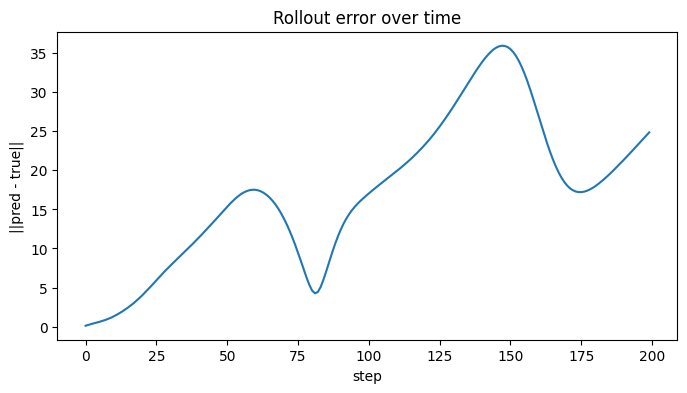

In [32]:
err = jnp.linalg.norm(preds - true_future, axis=1)

plt.figure(figsize=(8, 4))
plt.plot(err)
plt.xlabel("step")
plt.ylabel("||pred - true||")
plt.title("Rollout error over time")
plt.show()

In [47]:
X_vis, Y_vis = make_batch(random.fold_in(key_misc,123),cfg)

Y_hat,A = forward(params,X_vis,P,M,return_attn=True,attn_block_idx=cfg["n_layers"]-1)

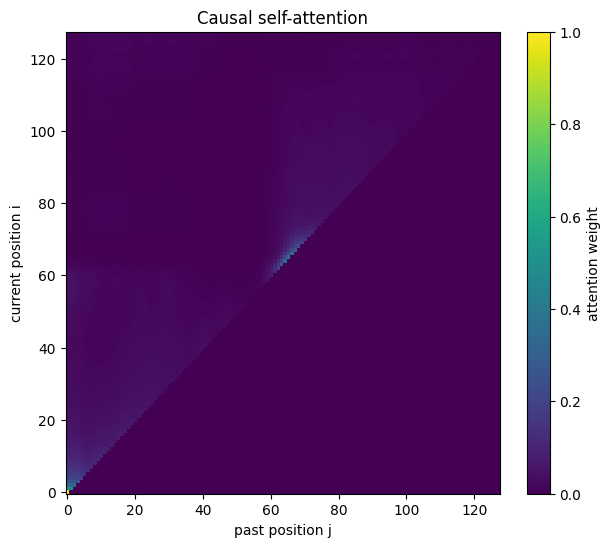

In [ ]:
b_idx = 0
h_idx = 0


A_mean = jnp.mean(A[b_idx],axis=0)

plt.figure(figsize=(7,6))
plt.imshow(A_mean, origin="lower", aspect="auto", cmap="viridis")
plt.colorbar(label="attention weight")
plt.xlabel("past position j")
plt.ylabel("current position i")
plt.title("Causal self-attention")
plt.show()